In [1]:
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
raw_dir = Path("../data/raw")
df = pd.read_csv("../data/annotated/ground_truth.csv")

print(f"Total receipts: {len(df)}")
print("\nCondition Distribution:")
print(df['condition'].value_counts())
print("\nData:")
print(df)

Total receipts: 22

Condition Distribution:
condition
fresh               13
moderately_faded     6
heavily_faded        3
Name: count, dtype: int64

Data:
          filename  amount        date                       store_branch  \
0   receipt_01.jpg    50.0  2026-05-10  7-Eleven Neribros Inc. Store#2006   
1   receipt_02.jpg   203.0  2026-05-10  7-Eleven Neribros Inc. Store#2006   
2   receipt_03.jpg    44.0  2026-05-10  7-Eleven Neribros Inc. Store#2006   
3   receipt_04.jpg    24.0  2026-05-11      7-Eleven Rhainella Store#2423   
4   receipt_05.jpg  1300.0  2026-05-10                    7-Connect Kiosk   
5   receipt_06.jpg  2000.0  2026-05-11      7-Eleven Rhainella Store#2423   
6   receipt_07.jpg    11.0  2026-05-11      7-Eleven Rhainella Store#2423   
7   receipt_08.jpg    73.0  2026-05-11      7-Eleven Rhainella Store#2423   
8   receipt_09.jpg    10.0  2026-05-11      7-Eleven Rhainella Store#2423   
9   receipt_10.jpg    81.0  2026-05-11      7-Eleven Rhainella Store#2423 

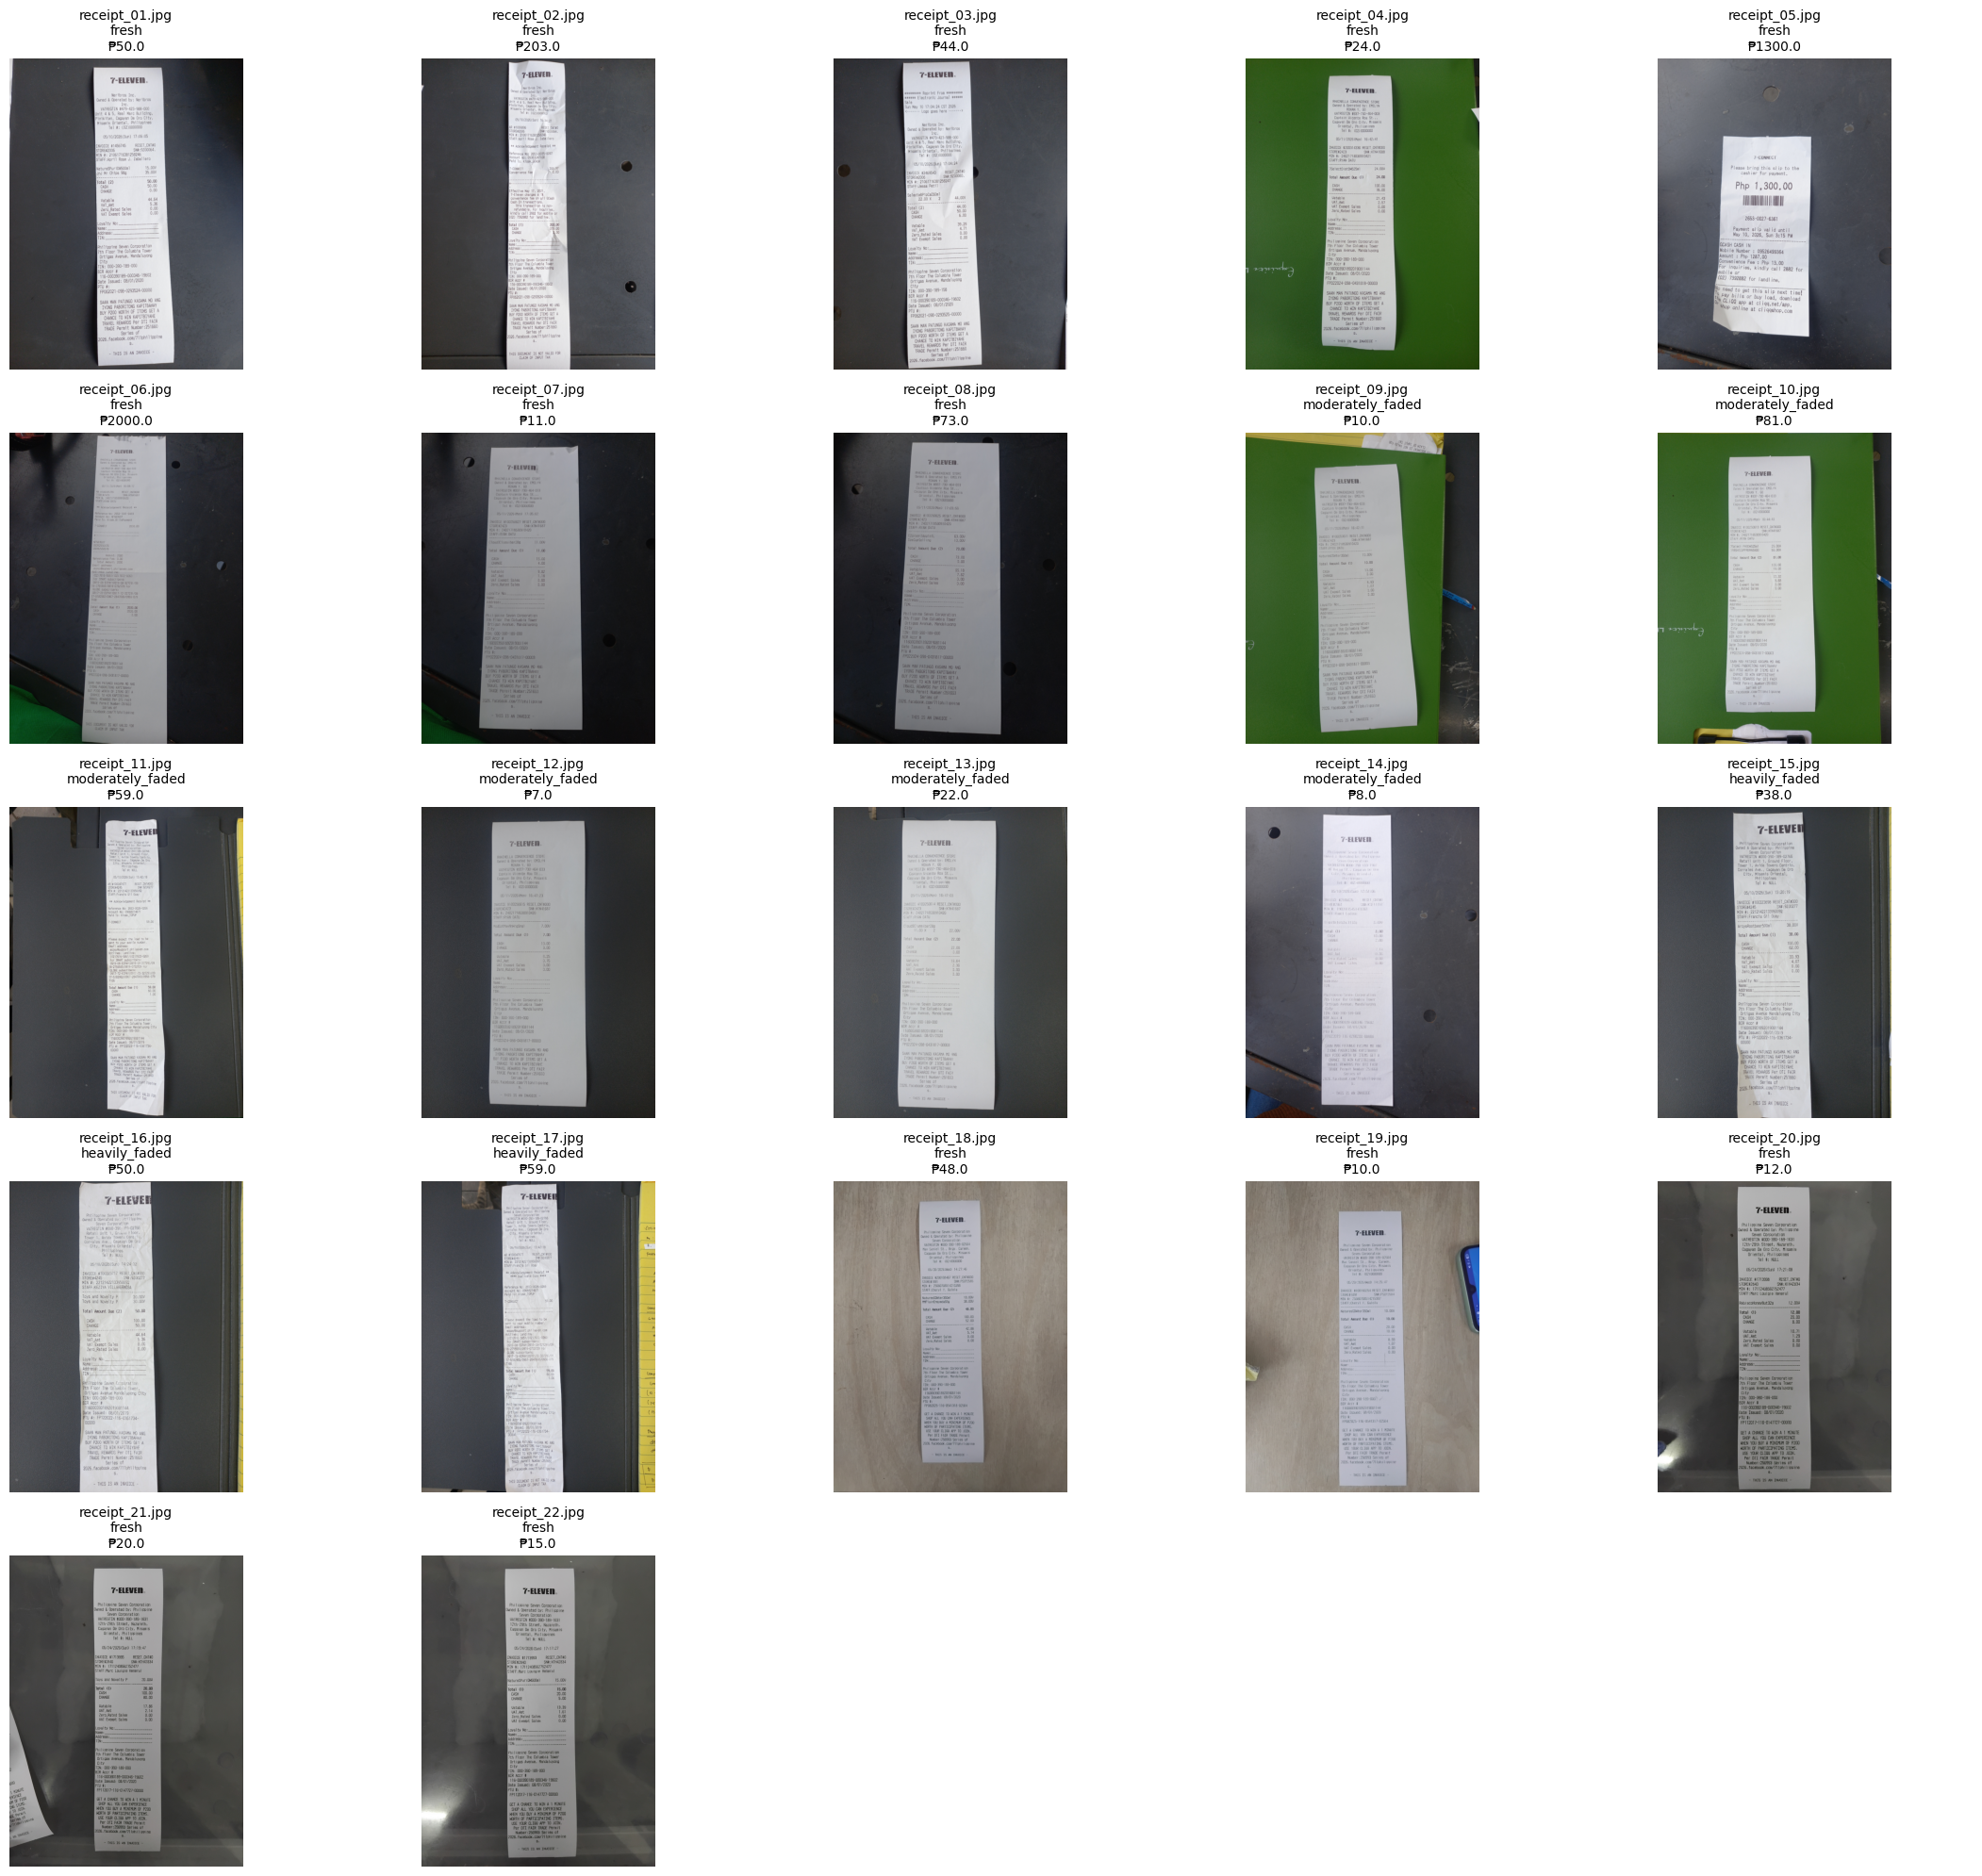

In [3]:
n = len(df)
ncols = 5
nrows = -(-n // ncols)  # ceiling division — rounds up automatically

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(22, nrows * 4))
axes = axes.flatten()

for i, row in df.iterrows():
    img = cv2.imread(str(raw_dir / row['filename']))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img_rgb)
    axes[i].set_title(f"{row['filename']}\n{row['condition']}\n₱{row['amount']}", fontsize=10)
    axes[i].axis('off')

# Hide any empty subplots if receipts don't fill the grid
for j in range(n, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig("../outputs/figures/receipts_overview.png", dpi=200)
plt.show()